<a href="https://colab.research.google.com/github/Basurero2/Clasificacion----validaci-n-de-modelos-y-metricas-de-evaluaci-n/blob/juan-carlos/Clasificacion_primeros_pasos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Clasificación: Primeros pasos**

En este proyecto, analizaremos datos de una campaña de marketing para la adhesión a inversiones. El objetivo es utilizar la información de los datos para predecir si los clientes de un banco invertirán su dinero o no.  

Esta predicción se realizará mediante **machine learning**, y este notebook contendrá los pasos para obtener un modelo capaz de hacer dichas predicciones, desde la **lectura**, **análisis exploratorio**, **separación** y **transformación** de los datos, hasta el **ajuste**, **evaluación** y **comparación** de modelos de clasificación.

# 1. Análisis exploratorio

## Realizando la lectura de los datos

Podemos leer los datos utilizando la biblioteca `pandas`. Por esta razón, importaremos la biblioteca con el comando `import pandas as pd`.  

Dado que el archivo de datos está en formato *csv*, realizaremos la lectura con la función [`read_csv()`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html).

In [4]:
import pandas as pd

In [5]:
datos = pd.read_csv('/content/marketing_inversiones.csv')
datos.head()

,edad,estado_civil,escolaridad,default,saldo,prestatario,ultimo_contacto,ct_contactos,adherencia_inversion
0,45,casado (a),superior,no,242,no,587,1,si
1,42,casado (a),secundaria,no,1289,no,250,4,si
2,23,soltero (a),superior,no,363,no,16,18,no
3,58,divorciado (a),superior,no,1382,no,700,1,si
4,50,casado (a),secundaria,no,3357,no,239,4,si


- default : paga o no paga, es bueno o mal cliente, (si : mal cliente; no : si paga, buen cliente)
- saldo : dinero que tiene en la cuenta
- prestatario : realizo prestamo en el banco
- ultimo_contacto : hace cuantos dias se realizo el ultimo contacto
- ct_contacto : cantidad de veces que se contacto con la persona
- adherencia_inversion : cliente se adherio o no a la campaña de inversionista (si va a invertir)






Para crear modelos de clasificación, necesitamos utilizar datos de calidad, sin inconsistencias y sin datos faltantes. Verificaremos si existen datos nulos y el tipo de datos de cada columna en la base de datos utilizando el método [`info()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html).

In [6]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1268 entries, 0 to 1267
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   edad                  1268 non-null   int64 
 1   estado_civil          1268 non-null   object
 2   escolaridad           1268 non-null   object
 3   default               1268 non-null   object
 4   saldo                 1268 non-null   int64 
 5   prestatario           1268 non-null   object
 6   ultimo_contacto       1268 non-null   int64 
 7   ct_contactos          1268 non-null   int64 
 8   adherencia_inversion  1268 non-null   object
dtypes: int64(4), object(5)
memory usage: 89.3+ KB


## Explorando los datos

Una etapa muy importante en proyectos de *machine learning* es la exploración y comprensión de los datos, conocida como **análisis exploratorio**. Podemos utilizar gráficos para verificar qué información contiene cada una de las columnas de la base de datos, así como identificar inconsistencias y patrones que puedan existir.  

Exploraremos cada una de las columnas de la base de datos utilizando la biblioteca `plotly`. Comenzaremos con las variables categóricas y luego analizaremos las variables numéricas.

### Variables categóricas

In [7]:
import plotly.express as px

In [8]:
px.histogram(datos, x="adherencia_inversion", text_auto=True, )

#### Estado civil

In [9]:
px.histogram(datos, x="estado_civil", text_auto=True, color="adherencia_inversion", barmode="group")

# gradica de distribucion de frecuencias
# x : valores mostraran su frencuencia
# color : se mostraran una diferenciacion de colores (leyenda) y proporciones de acuerdo a relacion
# a los valores de la columna "adherencia_inversion"
# barmode : como se mostraran esa proporcion de cada valor de x (group : apiladas al costado)

#### Default

In [10]:
px.histogram(datos, x="default", text_auto=True, color="adherencia_inversion", barmode="group")

#### Prestatario

In [11]:
px.histogram(datos, x="prestatario", text_auto=True, color="adherencia_inversion", barmode="group")

#### Escolaridad

In [12]:
px.histogram(datos, x="escolaridad", text_auto=True, color="adherencia_inversion", barmode="group")

Que sucede si aplicamos grafica a una variable cualitativa como cuantitativa

In [13]:
px.box(datos, x="escolaridad")

# vemos que al ser variables cualitativas no podemos obtener informacion ai usamos graficas o medidas de localizacion
# yaque aunque sean transformadas a numeros, no representa igual a una variable cuantitativa, siguen siendo cualitativas

# el valor que se le asocia representa una caracteristica y no una cantidad numerica

### Variables numéricas

In [14]:
datos.head()

,edad,estado_civil,escolaridad,default,saldo,prestatario,ultimo_contacto,ct_contactos,adherencia_inversion
0,45,casado (a),superior,no,242,no,587,1,si
1,42,casado (a),secundaria,no,1289,no,250,4,si
2,23,soltero (a),superior,no,363,no,16,18,no
3,58,divorciado (a),superior,no,1382,no,700,1,si
4,50,casado (a),secundaria,no,3357,no,239,4,si


#### Edad

In [15]:
px.box(datos, x = "edad")

In [16]:
px.box(datos, x = "edad", color="adherencia_inversion")

In [17]:
px.histogram(datos, x="edad", color="adherencia_inversion")

#### Saldo

In [18]:
px.box(datos, x = "saldo", color="adherencia_inversion")

In [19]:
px.histogram(datos, x="saldo", color="adherencia_inversion")

#### Ultimo contacto

In [20]:
px.box(datos, x = "ultimo_contacto", color="adherencia_inversion")

In [21]:
px.histogram(datos, x="ultimo_contacto", color="adherencia_inversion")

#### Cantidad de veces contactadas con el cliente

In [22]:
px.box(datos, x = "ct_contactos", color="adherencia_inversion")

Grafica de frecuencias para ver la forma de como estan distribuidas la variable ante si se adhiere al programa o no

In [23]:
px.histogram(datos, x="ct_contactos")

# distribucion de frecuencias del total

In [24]:
px.histogram(datos, x="ct_contactos", color="adherencia_inversion")

# distribucion de frecuencias  mostrando una segmentacion de color deacuerdo a valor relacionado
# con "adgerencia_inversion" para cada valor

# explicacion :
# color rojo : cantidad de personas que no se unieron
# color azul : cantidad de personas que se unieron
# eje x : cantidad de llamadas se que hizo al cliente

In [25]:
datos[datos["ct_contactos"] < 3 ].shape[0]

852

In [26]:
datos[datos["ct_contactos"] == 3].shape[0]   #cada barra representa la cantidad coincidencias con ese valor eje x

149

# 2. Tranformación de los datos

## Variables explicativas y variable de respuesta

Para realizar la predicción de los valores con un modelo de aprendizaje automático, necesitamos separar la variable objetivo de las variables explicativas. La variable **y** representa lo que queremos predecir, mientras que **x** incluye todas las variables que se utilizarán para explicar el comportamiento de **y**.

In [27]:
datos.head()   #conocer todas las variables de nuestra base de datos

,edad,estado_civil,escolaridad,default,saldo,prestatario,ultimo_contacto,ct_contactos,adherencia_inversion
0,45,casado (a),superior,no,242,no,587,1,si
1,42,casado (a),secundaria,no,1289,no,250,4,si
2,23,soltero (a),superior,no,363,no,16,18,no
3,58,divorciado (a),superior,no,1382,no,700,1,si
4,50,casado (a),secundaria,no,3357,no,239,4,si


In [28]:
y = datos["adherencia_inversion"]   #guardamos nuestra variable dependiente o respuesta, serie, vector
y.head()

,adherencia_inversion
0,si
1,si
2,no
3,si
4,si


In [29]:
X = datos.drop(columns="adherencia_inversion")  #variables independientes o explicativas, matriz
X.head()

,edad,estado_civil,escolaridad,default,saldo,prestatario,ultimo_contacto,ct_contactos
0,45,casado (a),superior,no,242,no,587,1
1,42,casado (a),secundaria,no,1289,no,250,4
2,23,soltero (a),superior,no,363,no,16,18
3,58,divorciado (a),superior,no,1382,no,700,1
4,50,casado (a),secundaria,no,3357,no,239,4


## Transformando las variables explicativas

Los algoritmos de aprendizaje automático no comprenden datos en formato de texto, por lo que debemos transformar los datos a un formato numérico para que el algoritmo pueda interpretar la información. Esta transformación debe realizarse de manera que no altere la información original del conjunto de datos, por lo que no basta con simplemente cambiar los valores a números aleatorios.

OneHotEncoder

los valores se convierten en columnas y luego los valores de esa variable se evalua, si llega a coincider en uan de las columnas se pone 1, y los demas 0 en esa evaluacion, asi hasta acabar los valores

OrdinalEncoder

para variables cateogricas que tengan un orden o jerarquia, o que consideres para tu modelo que los valores necesitan ser jerarquizados

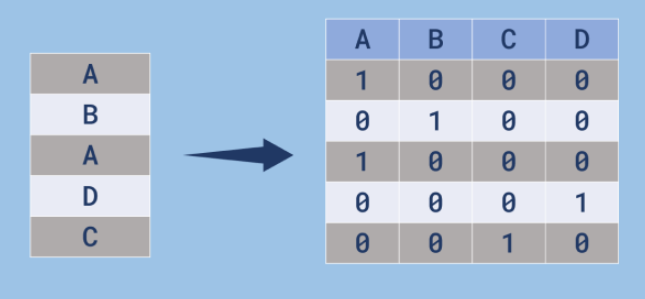

In [30]:
X.head()

# notemos que tenemos variables independientes que son string, entonces vamos a transformarlos en numero
# pero de modo que incluya peso para evitar mala interpretacion
# para ello usaremos OneHotEncoder

,edad,estado_civil,escolaridad,default,saldo,prestatario,ultimo_contacto,ct_contactos
0,45,casado (a),superior,no,242,no,587,1
1,42,casado (a),secundaria,no,1289,no,250,4
2,23,soltero (a),superior,no,363,no,16,18
3,58,divorciado (a),superior,no,1382,no,700,1
4,50,casado (a),secundaria,no,3357,no,239,4


In [31]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [32]:
columnas = X.columns    #obtener los nombres variables independiente
columnas

Index(['edad', 'estado_civil', 'escolaridad', 'default', 'saldo',
       'prestatario', 'ultimo_contacto', 'ct_contactos'],
      dtype='object')

In [33]:
one_hot = make_column_transformer((OneHotEncoder(drop="if_binary"),['estado_civil', 'escolaridad', 'default', 'prestatario']),
                                  remainder='passthrough',
                                  sparse_threshold=0,
                                  force_int_remainder_cols=False)

# one_hot : variable que almacena un objeto de clase ColumnTransformer : internamente hay una "tabla" vacia con encabezados
#   partida en 2 (onehotencoder : variables a las que se transformo,
#      remainder : variables que no se transformo (passthroguh), que aparecen una vez se ajuste con un DataFrame)
#      ademas que creara nuevas columnas de acuerdo a los valores que se le pase en el ajuste (fit), dinamico
#      aqui solo se crea la regla de que columnas tomar de partida para crear nuevas columnas

# make_column_transformer() : aplicar diferentes transformaciones (en este caso OneHotEncoder) a diferentes columnas al mismo tiempo
# - primer parametro : tupla de 2 datos, (tipo de transformacion, columnas a quienes se transformara)


# OneHotEncoder() : un tipo de transformacion
# - drop="if_binary" : se crea una columna para columnas que tenga solo 2 valores, y el sufijo del nombre de la columna creada
#     sera el valor con indice "1" cuando ordeno alfabeticamente los valores
#     ejemplo : ordena los valores ["no", si"] y la columna sera en base al valor indice 1 osea "si" : nombre_si
#     ahora en cada evluacion posterior si hay un valor "si" sera un "1" sino "0"

# todo esto se aplicara una vez que se le ajuste un DataFrame, esto es solo un orquestador con memoria

# demas parametros de make_column_transformer

# remainder : que se haran con encuentre columnas que no seran tratadas
# - "passthrough" : los deja pasar, no les hace nada, no los elimina, los mantiene igual

# sparse_threshold : todo sera un Numpy Array normal (denso) (mas facil leer), sino crea una matriz dispersa (ahorra memoria)

# force_int_remainder_cols : si los columnas no transformadas se le pasar en orden por su indice despues del ajuste
# - True : al pasarle un conjunto de prueba, los datos se pasaran deacuerdo al indice inicial
#     lo cual si es diferente orden las columnas, los datos seran llenados erroneamente
# - False : al pasarle un conjunto de prueba, los datos se pasaran deacuerdo al nombre de la columna
#     lo cual si es diferente el orden de las columnas, los datos iran a las columna donde coincidan sus nombre de columna


In [34]:
one_hot   #objeto ColumnTransformer vacio (naranja)

ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  sparse_threshold=0,
                  transformers=[('onehotencoder',
                                 OneHotEncoder(drop='if_binary'),
                                 ['estado_civil', 'escolaridad', 'default',
                                  'prestatario'])])

In [35]:
X = one_hot.fit_transform(X)
# ajustamos el objeto ColumnTransformer con un DataFrame para que transforme sus datos segun como se configuro
# el objeto (sparse_threshold = 0)
# X : se guardara los valores ajustados

# tambien el objeto one_hot guardara en su memoria los categorias de cada columna que se usara para crear
# nuevas columnas (transformadas), y se mostrara con tono azul cuando llamemos al objeto

#sobreescribimos nuetro DataFrame de variables independiente con un array con los datos transformados


In [36]:
X    #valores transformados en orden

array([[ 1.000e+00,  0.000e+00,  0.000e+00, ...,  2.420e+02,  5.870e+02,
         1.000e+00],
       [ 1.000e+00,  0.000e+00,  0.000e+00, ...,  1.289e+03,  2.500e+02,
         4.000e+00],
       [ 0.000e+00,  0.000e+00,  1.000e+00, ...,  3.630e+02,  1.600e+01,
         1.800e+01],
       ...,
       [ 0.000e+00,  0.000e+00,  1.000e+00, ..., -4.770e+02,  1.532e+03,
         2.000e+00],
       [ 1.000e+00,  0.000e+00,  0.000e+00, ...,  2.187e+03,  5.250e+02,
         3.000e+00],
       [ 0.000e+00,  0.000e+00,  1.000e+00, ...,  1.900e+01,  1.100e+02,
         2.000e+00]])

In [37]:
one_hot
# azul : objeto ya ajustado con un Dataframe, ya ha sido usado para transformar datos
# nos muestra la regla que tiene, que columnas se usaran para crea nuevas columnas segun los valores
# que se les pase al ajustar con un Dataframe
# tambien tiene en memoria las categorias (valores) de cada columna en onehotencoder


ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  sparse_threshold=0,
                  transformers=[('onehotencoder',
                                 OneHotEncoder(drop='if_binary'),
                                 ['estado_civil', 'escolaridad', 'default',
                                  'prestatario'])])

In [38]:
one_hot.get_feature_names_out(columnas)
# devuelve un array de columnas transformadas creadas : prefijo onehotencoder y sufijo segun su valores de la columna
# columnas no transformadas, por el parametro remainder = "passthrough" : prefijo remainder

# esto crea nombres de columnas segun los categorias por cada columna que sera transformadda del objeto
# ColumnTransformer ajustado anteriormente (memoria)
# solo genera no guarda nada, para despues crees un DataFrame con los valores transformados (array)

array(['onehotencoder__estado_civil_casado (a)',
       'onehotencoder__estado_civil_divorciado (a)',
       'onehotencoder__estado_civil_soltero (a)',
       'onehotencoder__escolaridad_primaria',
       'onehotencoder__escolaridad_secundaria',
       'onehotencoder__escolaridad_superior', 'onehotencoder__default_si',
       'onehotencoder__prestatario_si', 'remainder__edad',
       'remainder__saldo', 'remainder__ultimo_contacto',
       'remainder__ct_contactos'], dtype=object)

In [39]:
type(one_hot)

sklearn.compose._column_transformer.ColumnTransformer

In [40]:
pd.DataFrame(X, columns = one_hot.get_feature_names_out(columnas))
# creamos un DataFrame con los valores transformados al ajustar con los datos variables independientes
# y ponemos los nombres correspondientes en orden generados por et_feature_name_out(columnas : nomobres variables independientes)

,onehotencoder__estado_civil_casado (a),onehotencoder__estado_civil_divorciado (a),onehotencoder__estado_civil_soltero (a),onehotencoder__escolaridad_primaria,onehotencoder__escolaridad_secundaria,onehotencoder__escolaridad_superior,onehotencoder__default_si,onehotencoder__prestatario_si,remainder__edad,remainder__saldo,remainder__ultimo_contacto,remainder__ct_contactos
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,45.0,242.0,587.0,1.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,42.0,1289.0,250.0,4.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,23.0,363.0,16.0,18.0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,58.0,1382.0,700.0,1.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,50.0,3357.0,239.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1263,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,52.0,83.0,1223.0,6.0
1264,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,35.0,5958.0,215.0,1.0
1265,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,30.0,-477.0,1532.0,2.0
1266,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,42.0,2187.0,525.0,3.0


## Transformando la variable respuesta

Así como las variables explicativas, la variable objetivo también debe convertirse al formato numérico. Podemos representar una variable objetivo binaria como 0 o 1, donde 0 indica la ausencia de la característica de la variable y 1 representa su presencia.

In [41]:
from sklearn.preprocessing import LabelEncoder

In [42]:
label_encoder = LabelEncoder()   # guardmoas el modulo, usado para variable dependiente

In [43]:
type(label_encoder)

sklearn.preprocessing._label.LabelEncoder

In [44]:
y = label_encoder.fit_transform(y)

# sobreescribimos nuestro Serie de variable dependiente con valores transformados usando esa Serie

# los valores transformados asociados seran deacuerdo de orden alfabetico de los valores de la varaible dependiente

# ejemplo valores ordenados : [no, si] -->  no : 0,  si : 1

# ejemplo valores ordenados : [no, si, talvez]  --> no : 0, si : 1, talvez : 2

#devuelve un array con los valores transformados

In [45]:
y    # array con los valores transformados

array([1, 1, 0, ..., 1, 1, 1])

# 3 Ajustando modelos

## Dividiendo los datos entre entrenamiento y prueba

Para comprender si el modelo realmente está aprendiendo de los datos, necesitamos hacer una separación de los datos entre entrenamiento y prueba. Los datos de **entrenamiento** se utilizan para ajustar el modelo, mientras que los datos de **prueba** sirven para verificar el aprendizaje del modelo en datos que no fueron utilizados en el momento del ajuste.

<a href="https://ibb.co/2749Chh3"><img src="https://i.ibb.co/Y7sC1QQB/train-test.png" alt="train-test" border="0"></a>

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3 , stratify=y, random_state = 5)

# trains_tesT_split : generar 2 pares de conjuntos para el entrenamiento y prueba
# stratify : va a mantener la misma proporcion que hay en entre los datos de la variable que se le pase
#   por lo general se referencia a la variable dependiente
#   ejemplo : en una variable hay 100 valores de los cuales 80% son 1 y 20% son 0, entonces
#   en el conjunto conjunto entrenamiento habra la misma proporcion, igual en el conjunto prueba
#   de accuerdo a su cantidad (70% : entrenamiento, 30% : prueba)

# test_size : porcentaje de datos que se usara para el conjunto prueba
# random_size : semilla de aleatoridad para que nos de el misma seleccion

# importancia del stratify : evitar que en el conjunto entrenamiento solo haya 4 tipos de valores de
# de un total de 5 tipos de valores por ejeemplo, asi tener mayor prediccion

## Modelo de referencia - Baseline

El modelo más simple de clasificar los datos es simplemente utilizar un algoritmo que asigna todas las clasificaciones a la clase que tiene mayor frecuencia. Este algoritmo sirve como un criterio de comparación para identificar si los otros modelos tienen un rendimiento mejor que la clasificación más simple posible.

Dummy : clasificador tonto

Como obtiene el porcentaje de accuracy que sirve como base para los modelos de ML, que tiene que superior a esta prediccion basica

- por defecto DummySlector usa strategy : most_frequent, que va a predecir el valor mas frecuente de la variable dependiente

$$Accuracy = \frac{\text{Predicciones Correctas}}{\text{Total de Datos}}$$

Ejemplo usando estrategy most_frequent

1. 100 datos : 80 son 1, y 20 son 0
2. valor mas frecuente 1 (va a predecir solo este valor)
3. le pasamos los 100 datos, de los cuales 80 son 1 (80 acertos) y 20 son 0 (0 acertos)
4. Predicciones Correctas : sumamos los acierto : 80 + 0 = 80
5. Hallamos el Accuracy : 80/100 = 0.8
6. este modelo solo acertara un 80% de que sean el valor 1, dandole el valor de 1 a todos los datos y ver cuantos acerto, pero no predice cuantos son 0, pero en este caso se puede saber, pero ante varios clasificaciones (eg. 0, 1, 2), no se podra saber cuanto porcentaje predice para cada valor.
7. hay otras strategy que pueden usarse para diferentes tipos de prediccion, en este caso es una prediccion clasificatoria de 2 valores
8. en caso tu modelo no supere por mucho esta metrica debes mejorarlo

In [48]:
from sklearn.dummy import DummyClassifier

In [49]:
dummy = DummyClassifier()   #tipo de clasificador mas simple, usa por defecto "most_frequent"


In [50]:
(y_train == 1).sum()

np.int64(351)

In [51]:
(y_train == 0).sum()    #valor mas frecuente de variable dependiente del conjunto entrenamiento

np.int64(536)

In [52]:
dummy.fit(X_train, y_train)
# entrenamiento del baseline, predecir el valor mas frecuente de y_train el cual es 0
# asumira para nuevos conjuntos de prueba, que todos los valores de y seran 0 y ver cuantos acerto

# se usan el X_train aqui solo para corrobar que tienen la misma cnatidad de registros

DummyClassifier()

In [53]:
dummy.score(X_test, y_test)
# calcular el acurracy para el baseline que predice el valor de 0
#

0.6036745406824147

In [54]:
(y_test == 0).sum()/len(y_test)   #calculo de acurracy para conjunto prueba

np.float64(0.6036745406824147)

In [55]:
dummy.score(X_train, y_train)

0.6042841037204059

In [56]:
(y_train == 0).sum()/len(y_train)   #calculo de acurracy para conjunto entrenamiento

np.float64(0.6042841037204059)

## Árboles de Decisión

El modelo de árbol de decisión es muy utilizado debido a su alta **explicabilidad** y **procesamiento rápido**, manteniendo un rendimiento bastante interesante.

Se basa en decisiones simples tomadas por el algoritmo, separando los datos mediante comparaciones de **menor** y **mayor** en los valores de las columnas de la base de datos.

ejemplos para un nodo para clasificar
- x <= 230


GINI : varia entre un intervalo 0 a 1, donde
- 0 : completamente separados, clasificados
- 1 : completamento mezclado

**GINI** : nos indica que tan clasificado esta, si tiende a 0, esta bien clasificado y si tiende a 1 esta muy mezclado los valores
- si es 0.5 los valores estan completamente desordenados, punto mas estres, mayor analisis, nos indica que la proporcion de ambos valores es 50%, igual cantidad

$$G = 1 - (p_0^2 + p_1^2)$$

**GINI ponderado de los hijos** : sirve para identficar que proporcion es la mejor, si tiende a 0 es mejor, pero es coje el reparto si entre todos las variables probas, se escoje la variable que con sus datos en esa casilla se obtuvo el menor GINI ponderado de sus hijos menor que las demas


$$G_{hijos} = \left( \frac{n_{izq}}{n_{total}} \times G_{izq} \right) + \left( \frac{n_{der}}{n_{total}} \times G_{der} \right)$$


**Como clasifica este modelo**

Utiliza los valores de las variables independientes
1. para el primer nodo prueba con cada una de las variables y ver cual oibtiene un reparto donde el GINI ponderado sea el menor de todos

ejemplo :

total 100 datos de valores [0,1], escojemos x<=35 usando variable "saldo" para primer nodo


hijo izquierda :
- 90 datos (0 : 81, 1 : 9)
- porporcion : ${p_0}$ = 81/90 = 0.9,   ${p_1}$ = 9/90 = 0.1
- $GINI =  1 - ({0.9^2} + {0.1^2})$ = 0.18



hijo derecha :
- 10 datos (0 : 1, 1 : 9)
- proporcion :  ${p_0}$ = 1/10 = 0.1, ${p_1}$ = 9/10 = 0.9
- $GINI =  1 - ({0.1^2} + {0.9^2})$ = 0.18

GINI ponderado de los hijos
**texto en negrita**
$$G_{hijos} = \left( \frac{90}{100} \times 0.18 \right) + \left( \frac{10}{100} \times 0.18 \right)$$

$$G_{ponderado} = (0.9 \times 0.18) + (0.1 \times 0.18) = 0.162 + 0.018 = \mathbf{0.18}$$


Asi se prueba con los datos de otra variable, y asi hasta acabar todas las variables independientes, y comparamos cual tuvo el menor GINI ponderado y escojemos esa variable como punto de partida y asi continua con sus hijos nodos hasta llegar a GINI 0 en los nodos hijos



**Ganancia** : indicar de si un GINI pondera es bueno ante el GINI padre

$$\Delta G = G_{padre} - G_{ponderado} = 0.5 - 0 = 0.5$$


- Este caso es un ejemplo de perfeccion cuando el  GINI es 0 en ambos nodos hijos
- mientras mas grande es la ganancia es un indicar de que es un buen proporcion de reparto
- si llega a 0 la ganancia como este caso, nos indica que es el peor reparto XD, probar otra columna (variable independiente)


como calcula su puntaje de prediccion usando el **score(X,y)**

$$Accuracy = \frac{\sum (\text{Predicciones Correctas})}{\text{Total de Muestras}}$$

In [57]:
from sklearn.tree import DecisionTreeClassifier

In [58]:
modelo_arbol = DecisionTreeClassifier()

In [59]:
modelo_arbol.fit(X_train, y_train)
#ajustamos nuestro modelo arbol con el conjunto entrenamiento

DecisionTreeClassifier()

```python
valores_columnas = ['casado (a)',
                'divorciado (a)',
                'soltero (a)',
                'primaria',
                'secundaria',
                'superior',
                'default',
                'prestatario',
                'edad',
                'saldo',
                'ultimo_contacto',
                'ct_contactos']
```

In [60]:
valores_columnas = ['casado (a)',
                'divorciado (a)',
                'soltero (a)',
                'primaria',
                'secundaria',
                'superior',
                'default',
                'prestatario',
                'edad',
                'saldo',
                'ultimo_contacto',
                'ct_contactos']

# nombre de las variables explicativas

In [61]:
modelo_arbol.score(X_test, y_test)
# obtenemos el acurracy usando un conjunto de prueba
# estos datos seran evaluados a los parametros estsblecidos en cada clasificacion que calculo
# el modelo arbol en el entrenamiento

# parametros : son  x <= k, o x >= h, asi en cada clasificacion hasta llegar a GINI = 0

# concluimos que hay un gran desvalance con el puntaje de entrenamiento lo cual indica un overfitting

0.6850393700787402

In [62]:
modelo_arbol.score(X_train, y_train)
# obtenemos un accuracy de 100% yaque este modelo, analiza todos los casos para
# obtener los datos clasificados correctamente y obtener cuantos fueron 1 y 0
# usando su conjunto entrenamiento,    GINI = 0



1.0

**Explicacion del Grafico de arbol**

- primero pone colores por defecto deacuerdo a cuantos tipos de valores va a clasificar en orden ([0,1,2,...] : [naranja, azul, morado, ....])

- las tonalidades, mientras mas solido o fuerte es el color su GINI tiende a 0
- si la tonalidad es medio, como blanco su GINI es 0.5 o 0.66 si son tres tipos de valores

|Valor de Gini|Estado de la casilla|Interpretación|
|--|--|--|
|0.0 - 0.1| Oscuro (Naranja/Azul)|Excelente. Casi todos en este grupo son de la misma clase.|
|0.1 - 0.3| Color intermedio| Bueno. Hay una tendencia clara, pero todavía hay "ruido".|
|0.3 - 0.5| Claro / Blanco | Pobre. El operador no logró separar bien a la gente en este nodo.|



- True o False : esto indica si los valores de una variable escojida para clasificar (obtuvo el GINI ponderado menor que las demas en ese nodo), cumple con la condicion va al nodo hijo izquierda y sino va al nodo hijo derecha

**Datos en cada casilla**

- primero, es el nombre de la variable que se le paso en el parametro "feature_name" que se asocia a la columna por su indice, por eso se pasa en orden los nombres en el parametro para que coincida con el indice correcto

- gini : valor de gini en ese nodo, usado con los datos que hay en ese nodo (N)

- sample (N) : total de valores que hay en ese nodo (n_0 + n_1 = N)

- value : una array muestra frecuencia de cada tipo de dato en orden [0 : 90, 1 : 10] y que tmbien se le asocia un nombre a cada tipo en orden en el parametro class_names = ["no", "si"]

- class : es el tipo de dato mas frecuente en ese nodo, mostrando el tipo de dato (0 o 1) o su etiqueta si se le paso ("no" o "si")

**Observaciones** :

- si el GINI da 0 usando un sample de 1 , 2, 4, asi valores muy bajos, nos indica un *overfifting* yaque tuvo que ajustar bastantes nodos para llegar a clasificar hasta llegar a minimas cantidades, para mejorarlo se usa el parametro **max_depth** : que limita el maximo numero de niveles que puede tener el arbol

ejemplo de max_depth = 3

nivel 0 : nodo raiz, o principal

nivel 1 : 2 nodos

nivel 2 : 4 nodos

nivel 3 : 8 nodos

si llega hasta ahi, el arbol corta y se queda con los valores obtenidos hasta ahi, puede acabar en le nivel 1 normal, pero el maximo es 3 en este caso

- Si todos los datos X de una variable usada en un nodo son iguales es considerado como ruido, el modelo no puede clasificar o separarlo usando el operado "<=", por ello ahi muere el nodo, su GINI puede ser cualquiera




In [63]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

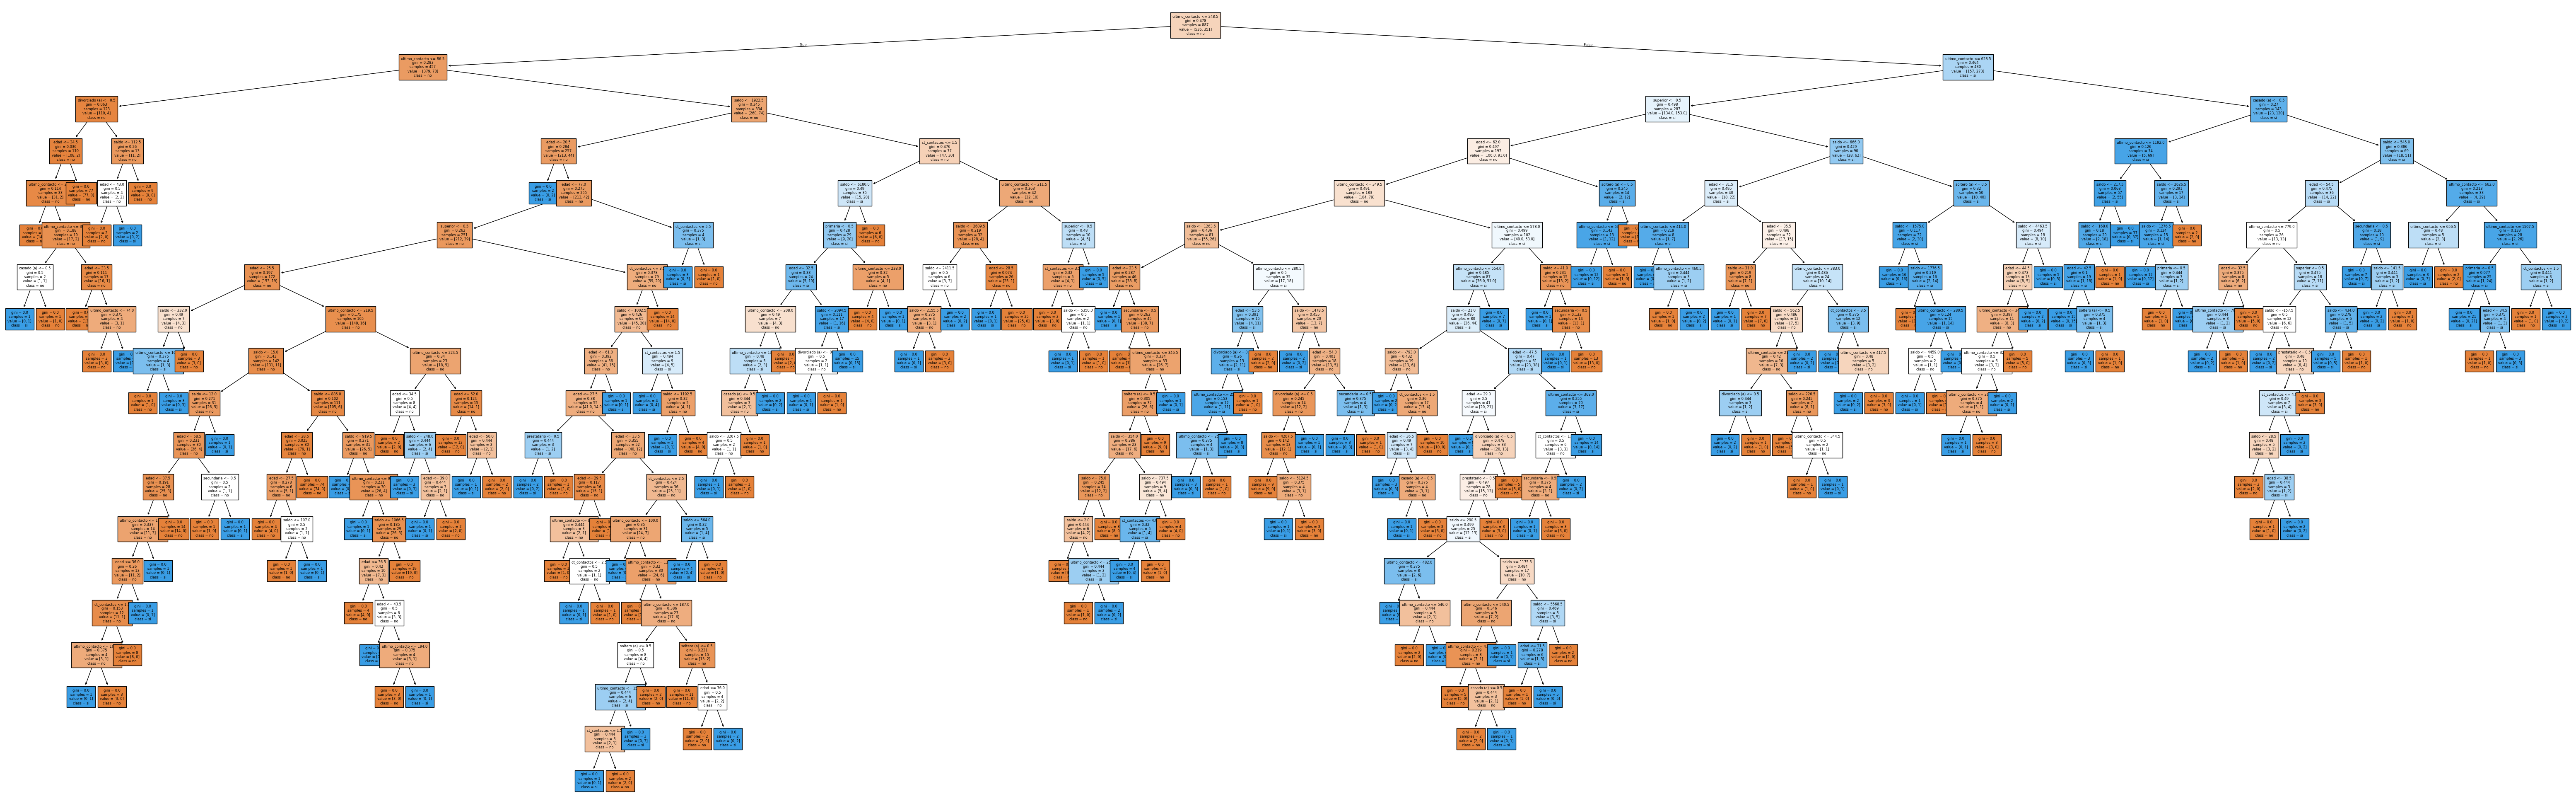

In [64]:
plt.figure(figsize=(80,25))
plot_tree(modelo_arbol, filled=True, class_names=["no","si"], fontsize=6, feature_names=valores_columnas);


# class_names : darle una clase o etiqueta al valor de 0 y 1 respectivamente.
# usamos la etiqueta de acuerdo a que esta asociado cada valor transformado
# - es como darle un etiqueta a los valores que esta clasificando el arbol

# feature_name : nombres de las variables o columnas las cuales segun el arbol elegira para clasificar en una casilla o nodo
# yaque al arbol solo mira indices entre columnas y filas, no ve los encabezados, ve una matriz



Mejorando el modelo arbol ante grandes volumenes de datos (big data) para evitar overfifting

In [65]:
modelo_arbol = DecisionTreeClassifier(max_depth=3, random_state = 5)
# creamos estructura modelo arbol
# max_depth : maxima niveles que tendra el arbol, donde nivel 0 es el nodo raiz
# random_state : pusismos el mismo valor para comparar con los mismo datos usados

In [66]:
modelo_arbol.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=5)

In [67]:
modelo_arbol.score(X_test, y_test)  #notamos que obtivmos un mejor puntaje que si usaramos una clasificacion hasta llegar a GINI 0

# esto indica que nuestro anterior modelo tenia overfifiting

0.7270341207349081

In [68]:
modelo_arbol.score(X_train, y_train)  # notamos que el puntaje con el conjunto entrenamiento es cercano con el de prueba

# concluimos que este modelo usando un maximo de 3 niveles es solido ante nuevos conjunto de datos

0.7519729425028185

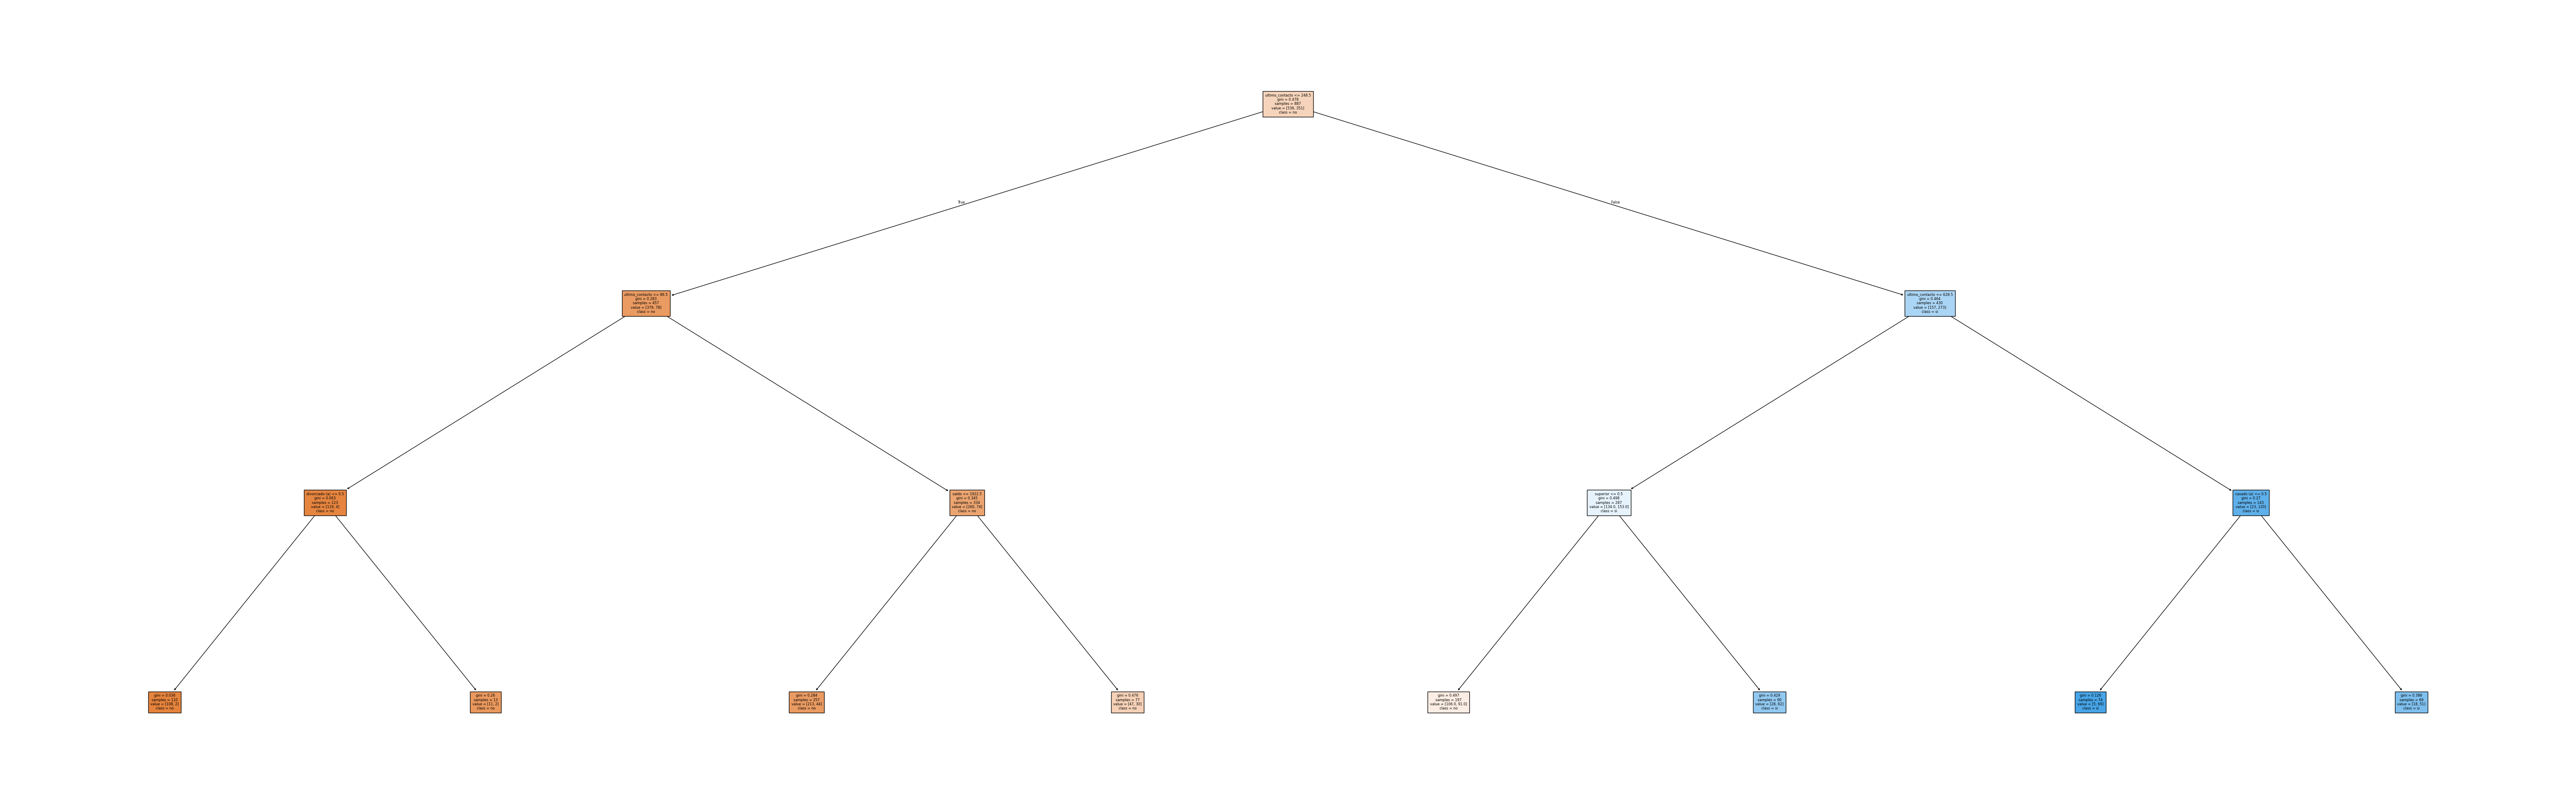

In [69]:
plt.figure(figsize=(80,25))
plot_tree(modelo_arbol, filled=True, class_names=["no","si"], fontsize=6, feature_names=valores_columnas);


# 4. Selección de modelos

## Normalizando los datos

Algunos algoritmos pueden asignar un mayor peso a los valores de las variables debido a la escala de los valores y no por la importancia de la clasificación de la variable objetivo. Por ejemplo, en una base de datos con las columnas **edad** y **salario**, el algoritmo puede dar un mayor peso de decisión a los valores del salario simplemente por estar en una escala mayor que los valores de la edad, y no porque la variable salario sea más importante que la variable edad.

En estos casos, necesitamos realizar una transformación en los datos para que estén en una misma escala, evitando que el algoritmo sea influenciado incorrectamente por los valores numéricos divergentes entre las variables.

$X_{sc} = \frac{X - X_{min}}{X_{max} - X_{min}} $

## KNN

El algoritmo KNN se basa en el cálculo de la distancia entre los registros de la base de datos y busca elementos que estén cerca unos de otros (vecinos) para tomar la decisión de clasificación.

Debido a que utiliza cálculos de distancia, este algoritmo está influenciado por la escala de las variables, y por eso es necesario realizar una transformación en los datos antes de utilizar este método.

## Escogiendo y serializando el mejor modelo

Al final de un proyecto de machine learning, debemos comparar los resultados de los modelos y elegir el que tenga el mejor rendimiento.

Podemos almacenar el modelo en un archivo serializado del tipo pickle para que sea utilizado en producción, es decir, en datos del mundo real para atender las necesidades del problema que necesita ser resuelto.

```python
nuevo_dato = {
    'edad': [45],
    'estado_civil':['soltero (a)'],
    'escolaridad':['superior'],
    'default': ['no'],
    'saldo': [23040],
    'prestatario': ['no'],
    'ultimo_contacto': [800],
    'ct_contactos': [4]
}
```

# Actividades

## Actividad Aula 1

Después de estudiar los conceptos de esta clase, ¡ha llegado el momento de practicar!

Vamos a practicar lo que se presentó en la clase a partir de algunas actividades, pero utilizando un conjunto de datos diferente al presentado en la clase. El tema de la base de datos es la de churn de clientes. El churn es una métrica que indica a los clientes que cancelan el servicio en un determinado período de tiempo.

Los desafíos siguen una secuencia de tareas, sirviendo como un proyecto secundario, que se realizará a lo largo de las clases del curso. Para realizar los desafíos, descarga la Base de datos - Desafío.






Recuerda que la práctica es fundamental para mejorar tus habilidades en Machine Learning. Con cada actividad, estarás un paso más cerca de dominar este campo de la tecnología. Utiliza los recursos disponibles, colabora con tus compañeros y no tengas miedo de cometer errores. Después de todo, es con los desafíos que crecemos.

1 - La primera etapa en un proyecto de Machine Learning es la obtención de datos. A partir de esta obtención, podemos leer los datos para construir un modelo. Como tarea inicial, realiza la lectura de la base de datos y verifica la presencia de datos nulos. Además, elimina la columna 'id_cliente', ya que este tipo de información única para cada fila no es útil para su uso en modelos de machine learning.

Conociendo los datos

In [70]:
import pandas as pd

In [72]:
datos_1 = pd.read_csv('/content/churn.csv')
datos_1.head()

,id_cliente,score_credito,pais,sexo_biologico,edad,años_de_cliente,saldo,servicios_adquiridos,tiene_tarjeta_credito,miembro_activo,salario_estimado,churn
0,15634602,619,Francia,Mujer,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,España,Mujer,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,Francia,Mujer,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,Francia,Mujer,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,España,Mujer,43,2,125510.82,1,1,1,79084.10,0


In [73]:
datos_1 = datos_1.drop(columns="id_cliente")
#eliminamos id del cliente ya que es una identificacion para cada fila la cual ya hace el indice

In [74]:
datos_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   score_credito          10000 non-null  int64  
 1   pais                   10000 non-null  object 
 2   sexo_biologico         10000 non-null  object 
 3   edad                   10000 non-null  int64  
 4   años_de_cliente        10000 non-null  int64  
 5   saldo                  10000 non-null  float64
 6   servicios_adquiridos   10000 non-null  int64  
 7   tiene_tarjeta_credito  10000 non-null  int64  
 8   miembro_activo         10000 non-null  int64  
 9   salario_estimado       10000 non-null  float64
 10  churn                  10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [75]:
datos_1.isnull().sum()   #comprobamos que no hay valores nulos

,0
score_credito,0
pais,0
sexo_biologico,0
edad,0
años_de_cliente,0
saldo,0
servicios_adquiridos,0
tiene_tarjeta_credito,0
miembro_activo,0
salario_estimado,0


In [76]:
(datos_1 == "").sum()    #comprobamos que no haya valores vacios

,0
score_credito,0
pais,0
sexo_biologico,0
edad,0
años_de_cliente,0
saldo,0
servicios_adquiridos,0
tiene_tarjeta_credito,0
miembro_activo,0
salario_estimado,0


2 - Después de leer los datos, es importante conocer los datos, revisando inconsistencias y entendiendo el comportamiento de cada una de las columnas. En esta tarea, realiza un análisis exploratorio utilizando gráficos para las variables categóricas de la base de datos, incluyendo la variable objetivo churn. Para estas variables, se pueden utilizar gráficos de barras para contar las categorías y hacer un agrupamiento por colores de acuerdo con las categorías de la variable objetivo.


Analisis Exploratorio

In [77]:
import plotly.express as px

In [78]:
datos_1.head(5)

,score_credito,pais,sexo_biologico,edad,años_de_cliente,saldo,servicios_adquiridos,tiene_tarjeta_credito,miembro_activo,salario_estimado,churn
0,619,Francia,Mujer,42,2,0.00,1,1,1,101348.88,1
1,608,España,Mujer,41,1,83807.86,1,0,1,112542.58,0
2,502,Francia,Mujer,42,8,159660.80,3,1,0,113931.57,1
3,699,Francia,Mujer,39,1,0.00,2,0,0,93826.63,0
4,850,España,Mujer,43,2,125510.82,1,1,1,79084.10,0


variables cualitativas
- pais : de que pais es el cliente
- sexo_biologico : es hombre o mujer
- tiene_tarjeta_credito : 1 (si), 0 (no)
- miembro_activo : 1 (si), 0 (no)
- churn : el cliente se fue (1 : si), o no (0 : no)

In [79]:
px.histogram(datos_1, x="pais", color="churn", barmode="group", color_discrete_map= {1 : "#FF4B4B", 0:"#007BFF"})

# color_discrete_map : especificamos un color para cada valor de "churn" para mejor vizualizacion respecto
# a que representa esos valores
# 1 : cliente se fue, o cnacelo su servicio - rojo
# 0 : cliente no cancelo y sigue con el servicio - azul

In [80]:
px.histogram(datos_1, x="sexo_biologico", color="churn", barmode="group", color_discrete_map= {1 : "#FF4B4B", 0:"#007BFF"})

In [81]:
px.histogram(datos_1, x="tiene_tarjeta_credito", color="churn", barmode="group", color_discrete_map= {1 : "#FF4B4B", 0:"#007BFF"})

In [82]:
px.histogram(datos_1, x="miembro_activo", color="churn", barmode="group", color_discrete_map= {1 : "#FF4B4B", 0:"#007BFF"})

3 - Después de explorar las variables categóricas, es el turno de las variables numéricas. Construye gráficos de distribución como boxplots o histogramas para analizar el comportamiento de los valores numéricos y verificar si hay valores inconsistentes.

variables cuantitativas
- score_credito : que tan confiable es la persona, punto de confianza
- edad
- años_de_cliente : años usando el servicio
- saldo
- servicios_adquiridos : cantidad de servicios usando
- salario_estimado

**Score_credito**

In [83]:
px.box(datos_1, x="score_credito", color="churn", color_discrete_map= {1 : "#FF4B4B", 0:"#007BFF"})

In [84]:
px.histogram(datos_1, x="score_credito", color="churn", color_discrete_map= {1 : "#FF4B4B", 0:"#007BFF"})

**Edad**

In [85]:
px.box(datos_1, x="edad", color="churn", color_discrete_map= {1 : "#FF4B4B", 0:"#007BFF"})

In [86]:
px.histogram(datos_1, x="edad", color="churn", color_discrete_map= {1 : "#FF4B4B", 0:"#007BFF"})

Años_de_cliente

In [87]:
px.box(datos_1, x="años_de_cliente", color="churn", color_discrete_map= {1 : "#FF4B4B", 0:"#007BFF"})

In [88]:
px.histogram(datos_1, x="años_de_cliente", color="churn", barmode="group", color_discrete_map= {1 : "#FF4B4B", 0:"#007BFF"})

**Saldo**

In [89]:
px.box(datos_1, x="saldo", color="churn", color_discrete_map= {1 : "#FF4B4B", 0:"#007BFF"})

In [90]:
px.histogram(datos_1, x="saldo", color="churn", color_discrete_map= {1 : "#FF4B4B", 0:"#007BFF"})

**Servicios_adquiridos**

In [91]:
px.box(datos_1, x="servicios_adquiridos", color="churn", color_discrete_map= {1 : "#FF4B4B", 0:"#007BFF"})

In [92]:
px.histogram(datos_1, x="servicios_adquiridos", color="churn", barmode="group", color_discrete_map= {1 : "#FF4B4B", 0:"#007BFF"})

**Salario_estimado**

In [93]:
px.box(datos_1, x="salario_estimado", color="churn", color_discrete_map= {1 : "#FF4B4B", 0:"#007BFF"})

In [94]:
px.histogram(datos_1, x="salario_estimado", color="churn", color_discrete_map= {1 : "#FF4B4B", 0:"#007BFF"})

## Actividad aula 2

Después de estudiar los conceptos de esta clase, ¡ha llegado el momento de practicar!

Vamos a practicar lo que se presentó en la clase a partir de algunas actividades, pero utilizando un conjunto de datos diferente al presentado en la clase. El tema de la base de datos es la de churn de clientes. El churn es una métrica que indica a los clientes que cancelan el servicio en un determinado período de tiempo.

Los desafíos siguen una secuencia de tareas, sirviendo como un proyecto secundario, que se realizará a lo largo de las clases del curso. Para realizar los desafíos, descarga la Base de datos - Desafío.

La búsqueda de la solución a cualquier desafío comienza con la exploración y comprensión profunda del problema. Tómate un tiempo para comprender la necesidad de cada cuestión y desarrolla, con base en tu aprendizaje, las posibles soluciones. Además, recuerda que la práctica constante es la clave para el perfeccionamiento. A medida que aplicas lo que aprendes, los conceptos se solidifican y se convierten en parte de tu conocimiento práctico.

1. Para utilizar los datos en los algoritmos de Machine Learning, necesitamos informar cuáles son las variables explicativas y cuál es la variable objetivo. En este desafío, realiza la separación de la base de datos de churn entre las variables explicativas, almacenando en una variable x y la variable objetivo en y.

In [95]:
datos_1.head()

,score_credito,pais,sexo_biologico,edad,años_de_cliente,saldo,servicios_adquiridos,tiene_tarjeta_credito,miembro_activo,salario_estimado,churn
0,619,Francia,Mujer,42,2,0.00,1,1,1,101348.88,1
1,608,España,Mujer,41,1,83807.86,1,0,1,112542.58,0
2,502,Francia,Mujer,42,8,159660.80,3,1,0,113931.57,1
3,699,Francia,Mujer,39,1,0.00,2,0,0,93826.63,0
4,850,España,Mujer,43,2,125510.82,1,1,1,79084.10,0


In [96]:
X_1 = datos_1.drop(columns="churn")  #variables explicativas
X_1.head(2)

,score_credito,pais,sexo_biologico,edad,años_de_cliente,saldo,servicios_adquiridos,tiene_tarjeta_credito,miembro_activo,salario_estimado
0,619,Francia,Mujer,42,2,0.00,1,1,1,101348.88
1,608,España,Mujer,41,1,83807.86,1,0,1,112542.58


In [97]:
y_1 = datos_1["churn"]   #variable respuesta, dependentiente
y_1.head(2)

,churn
0,1
1,0


2. Las variables categóricas que están en formato de texto no pueden ser utilizadas directamente en los modelos de Machine Learning. En este desafío, realiza la transformación de las variables categóricas al formato numérico utilizando el OneHotEncoder, utilizando el parámetro drop='if_binary' si alguna variable tiene solo 2 categorías.

In [98]:
X_1.head(5)

,score_credito,pais,sexo_biologico,edad,años_de_cliente,saldo,servicios_adquiridos,tiene_tarjeta_credito,miembro_activo,salario_estimado
0,619,Francia,Mujer,42,2,0.00,1,1,1,101348.88
1,608,España,Mujer,41,1,83807.86,1,0,1,112542.58
2,502,Francia,Mujer,42,8,159660.80,3,1,0,113931.57
3,699,Francia,Mujer,39,1,0.00,2,0,0,93826.63
4,850,España,Mujer,43,2,125510.82,1,1,1,79084.10


In [99]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [100]:
one_hot_1 = make_column_transformer((OneHotEncoder(drop='if_binary'),['pais', 'sexo_biologico', 'tiene_tarjeta_credito', 'miembro_activo']),
                                    remainder='passthrough',
                                    sparse_threshold=0,
                                    force_int_remainder_cols=False)

#orquestador listo, con la formula para usarse para transformar valores

In [101]:
columnas_1 = X_1.columns   #nombres de variables explicativas
columnas_1

Index(['score_credito', 'pais', 'sexo_biologico', 'edad', 'años_de_cliente',
       'saldo', 'servicios_adquiridos', 'tiene_tarjeta_credito',
       'miembro_activo', 'salario_estimado'],
      dtype='object')

In [102]:
X_1 = one_hot_1.fit_transform(X_1)   #sobreescribimos nuestra DF variables explicativas
X_1

array([[0.0000000e+00, 0.0000000e+00, 1.0000000e+00, ..., 0.0000000e+00,
        1.0000000e+00, 1.0134888e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, ..., 8.3807860e+04,
        1.0000000e+00, 1.1254258e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, ..., 1.5966080e+05,
        3.0000000e+00, 1.1393157e+05],
       ...,
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, ..., 0.0000000e+00,
        1.0000000e+00, 4.2085580e+04],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 7.5075310e+04,
        2.0000000e+00, 9.2888520e+04],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, ..., 1.3014279e+05,
        1.0000000e+00, 3.8190780e+04]])

In [103]:
one_hot_1
#orquestador ya ajustado, contiene las categorias para crear un array de columnas nuevas

ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  sparse_threshold=0,
                  transformers=[('onehotencoder',
                                 OneHotEncoder(drop='if_binary'),
                                 ['pais', 'sexo_biologico',
                                  'tiene_tarjeta_credito', 'miembro_activo'])])

In [104]:
one_hot_1.get_feature_names_out(columnas_1)
#genera nombres de columnas creadas apartir de categorias obtenidas al ajustar con el X_1 (dataframe)

array(['onehotencoder__pais_Alemania', 'onehotencoder__pais_España',
       'onehotencoder__pais_Francia',
       'onehotencoder__sexo_biologico_Mujer',
       'onehotencoder__tiene_tarjeta_credito_1',
       'onehotencoder__miembro_activo_1', 'remainder__score_credito',
       'remainder__edad', 'remainder__años_de_cliente',
       'remainder__saldo', 'remainder__servicios_adquiridos',
       'remainder__salario_estimado'], dtype=object)

In [105]:
pd.DataFrame(X_1, columns=one_hot_1.get_feature_names_out(columnas_1))

,onehotencoder__pais_Alemania,onehotencoder__pais_España,onehotencoder__pais_Francia,onehotencoder__sexo_biologico_Mujer,onehotencoder__tiene_tarjeta_credito_1,onehotencoder__miembro_activo_1,remainder__score_credito,remainder__edad,remainder__años_de_cliente,remainder__saldo,remainder__servicios_adquiridos,remainder__salario_estimado
0,0.0,0.0,1.0,1.0,1.0,1.0,619.0,42.0,2.0,0.00,1.0,101348.88
1,0.0,1.0,0.0,1.0,0.0,1.0,608.0,41.0,1.0,83807.86,1.0,112542.58
2,0.0,0.0,1.0,1.0,1.0,0.0,502.0,42.0,8.0,159660.80,3.0,113931.57
3,0.0,0.0,1.0,1.0,0.0,0.0,699.0,39.0,1.0,0.00,2.0,93826.63
4,0.0,1.0,0.0,1.0,1.0,1.0,850.0,43.0,2.0,125510.82,1.0,79084.10
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.0,0.0,1.0,0.0,1.0,0.0,771.0,39.0,5.0,0.00,2.0,96270.64
9996,0.0,0.0,1.0,0.0,1.0,1.0,516.0,35.0,10.0,57369.61,1.0,101699.77
9997,0.0,0.0,1.0,1.0,0.0,1.0,709.0,36.0,7.0,0.00,1.0,42085.58
9998,1.0,0.0,0.0,0.0,1.0,0.0,772.0,42.0,3.0,75075.31,2.0,92888.52


3. La variable objetivo, como es de tipo categórica, también necesita pasar por un tratamiento similar al de las variables explicativas categóricas para que pueda ser utilizada en los algoritmos. En esta tarea, utiliza el método LabelEncoder para realizar la transformación de la variable churn.

In [106]:
from sklearn.preprocessing import LabelEncoder

In [107]:
label_encoder = LabelEncoder()   #tipo de transformador, hecho para variable dependiente

In [108]:
y_1 = label_encoder.fit_transform(y_1)
#fit_transform : aplicar la el transformador pasandole una conjunto
y_1  # numpy array



array([1, 0, 1, ..., 1, 1, 0])

## Actividad aula 3

Después de estudiar los conceptos de esta clase, ¡ha llegado el momento de practicar!

Vamos a practicar lo que se presentó en la clase a partir de algunas actividades, pero utilizando un conjunto de datos diferente al presentado en la clase. El tema de la base de datos es la de churn de clientes. El churn es una métrica que indica a los clientes que cancelan el servicio en un determinado período de tiempo.

Los desafíos siguen una secuencia de tareas, sirviendo como un proyecto secundario, que se realizará a lo largo de las clases del curso. Para realizar los desafíos, descarga la Base de datos - Desafío.

Para desarrollar este desafío, dedica un tiempo a reflexionar y explorar. Analiza cuidadosamente los datos y las instrucciones de los enunciados de cada pregunta. La colaboración puede proporcionar ideas valiosas. Por eso, no dudes en colaborar con tus compañeros en la comunidad, intercambiar ideas y compartir soluciones en conjunto.

1. La separación de los datos entre conjunto de entrenamiento y prueba es esencial para comprender si un modelo está logrando aprender los patrones y generalizar a nuevos datos. En esta tarea, realiza la división de la base de datos entre entrenamiento y prueba de forma estratificada.

In [109]:
from sklearn.model_selection import train_test_split

In [110]:
X_1   # datos variables independiente transformadas, array

array([[0.0000000e+00, 0.0000000e+00, 1.0000000e+00, ..., 0.0000000e+00,
        1.0000000e+00, 1.0134888e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, ..., 8.3807860e+04,
        1.0000000e+00, 1.1254258e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, ..., 1.5966080e+05,
        3.0000000e+00, 1.1393157e+05],
       ...,
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, ..., 0.0000000e+00,
        1.0000000e+00, 4.2085580e+04],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 7.5075310e+04,
        2.0000000e+00, 9.2888520e+04],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, ..., 1.3014279e+05,
        1.0000000e+00, 3.8190780e+04]])

In [111]:
y_1  # datos variable dependiente, array

array([1, 0, 1, ..., 1, 1, 0])

In [112]:
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.3, stratify=y_1, random_state=10)

2. Un modelo base es muy importante para definir un criterio de comparación para modelos más complejos. En esta etapa, crea un modelo base con el DummyClassifier y encuentra la tasa de acierto con el método score.

In [115]:
from sklearn.dummy import DummyClassifier

In [125]:
dummy_1 = DummyClassifier()

In [126]:
dummy_1    #objeto Dummy creado pero no ajustado

DummyClassifier()

In [127]:
dummy_1.fit(X_train_1,y_train_1)  # modelo ajustado con conjunto entrenamiento
                                  # ya sabe que valor va a pedecir, el mas frecuente (y_train_1)

DummyClassifier()

In [128]:
dummy_1.score(X_train_1,y_train_1)  # acurracy obtenido con conjunto entrenamiento

0.7962857142857143

In [129]:
dummy_1.score(X_test_1,y_test_1)   # accuracy cuando se pasa conjunto prueba

0.7963333333333333

3. El árbol de decisión es un algoritmo que realiza las clasificaciones a partir de decisiones simples tomadas a partir de los datos. Debemos tener cierto cuidado de no utilizar una profundidad muy grande, porque esto puede provocar un sobreajuste del modelo a los datos de entrenamiento. En este desafío, crea un modelo de árbol de decisión con el parámetro max_depth=4, evalúa el desempeño del modelo en los datos de prueba y visualiza las decisiones del árbol usando el método plot_tree.

In [131]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

In [134]:
model_tree_1 = DecisionTreeClassifier(max_depth=4)  #modelo arbol creado, con 4 niveles como maximo
model_tree_1

DecisionTreeClassifier(max_depth=4)

In [135]:
model_tree_1.fit(X_train_1, y_train_1)   #modelo entrenado con conjunto entrenamiento

DecisionTreeClassifier(max_depth=4)

In [136]:
model_tree_1.score(X_train_1, y_train_1)  # puntaje hallado con el conjunto entrenamiento

0.8514285714285714

In [138]:
model_tree_1.score(X_test_1, y_test_1)   # puntaje hallado de prediccion con el conjunto prueba


0.8493333333333334

Comparar el puntaje del modelo arbol con el modelo Dummy para ver si esta clasificiacion predictiva hay mejora, sino indicaria que nuestros datos no sirven XD,

Tambien es usado como un modelo Baseline ante modelo predictivos mas complejos, supongamos que el Dummy es el modelo baselino nivel 0 y el arbol modelo baseline nivel 1, es como un segundo filtro, pero se recomienda igual comparar los modelos mas complejos con ambos

Y si se compara con el score o accuracy usando el conjunto prueba

In [139]:
model_tree_1.score(X_test_1, y_test_1) > dummy_1.score(X_test_1, y_test_1)

#indica que el score o accuracy de nuestro modelo arbol es mayor que el de dummy

True

In [140]:
model_tree_1.score(X_test_1, y_test_1) - dummy_1.score(X_test_1, y_test_1)

#indica el porcentaje de mejora del modelo arbol respecto al modelo dummy

0.05300000000000005

Grafica arbol con 4 niveles como maximo

In [141]:
one_hot_1.get_feature_names_out(columnas_1)
# nomnbres columnas creadas en el transformador, muestra tambien cuantas columnas hay en total

array(['onehotencoder__pais_Alemania', 'onehotencoder__pais_España',
       'onehotencoder__pais_Francia',
       'onehotencoder__sexo_biologico_Mujer',
       'onehotencoder__tiene_tarjeta_credito_1',
       'onehotencoder__miembro_activo_1', 'remainder__score_credito',
       'remainder__edad', 'remainder__años_de_cliente',
       'remainder__saldo', 'remainder__servicios_adquiridos',
       'remainder__salario_estimado'], dtype=object)

In [145]:
valores_columnas_1 = ['pais_Alemania', 'pais_España',
       'pais_Francia',
       'sexo_biologico_Mujer',
       'tiene_tarjeta_credito_1',
       'miembro_activo_1', 'score_credito',
       'edad', 'años_de_cliente',
       'saldo', 'servicios_adquiridos',
       'salario_estimado']

# nombres de las variables independientes para suarlo como etiqueta a
# las columnas del array datos de variables independientes en el plot_tree

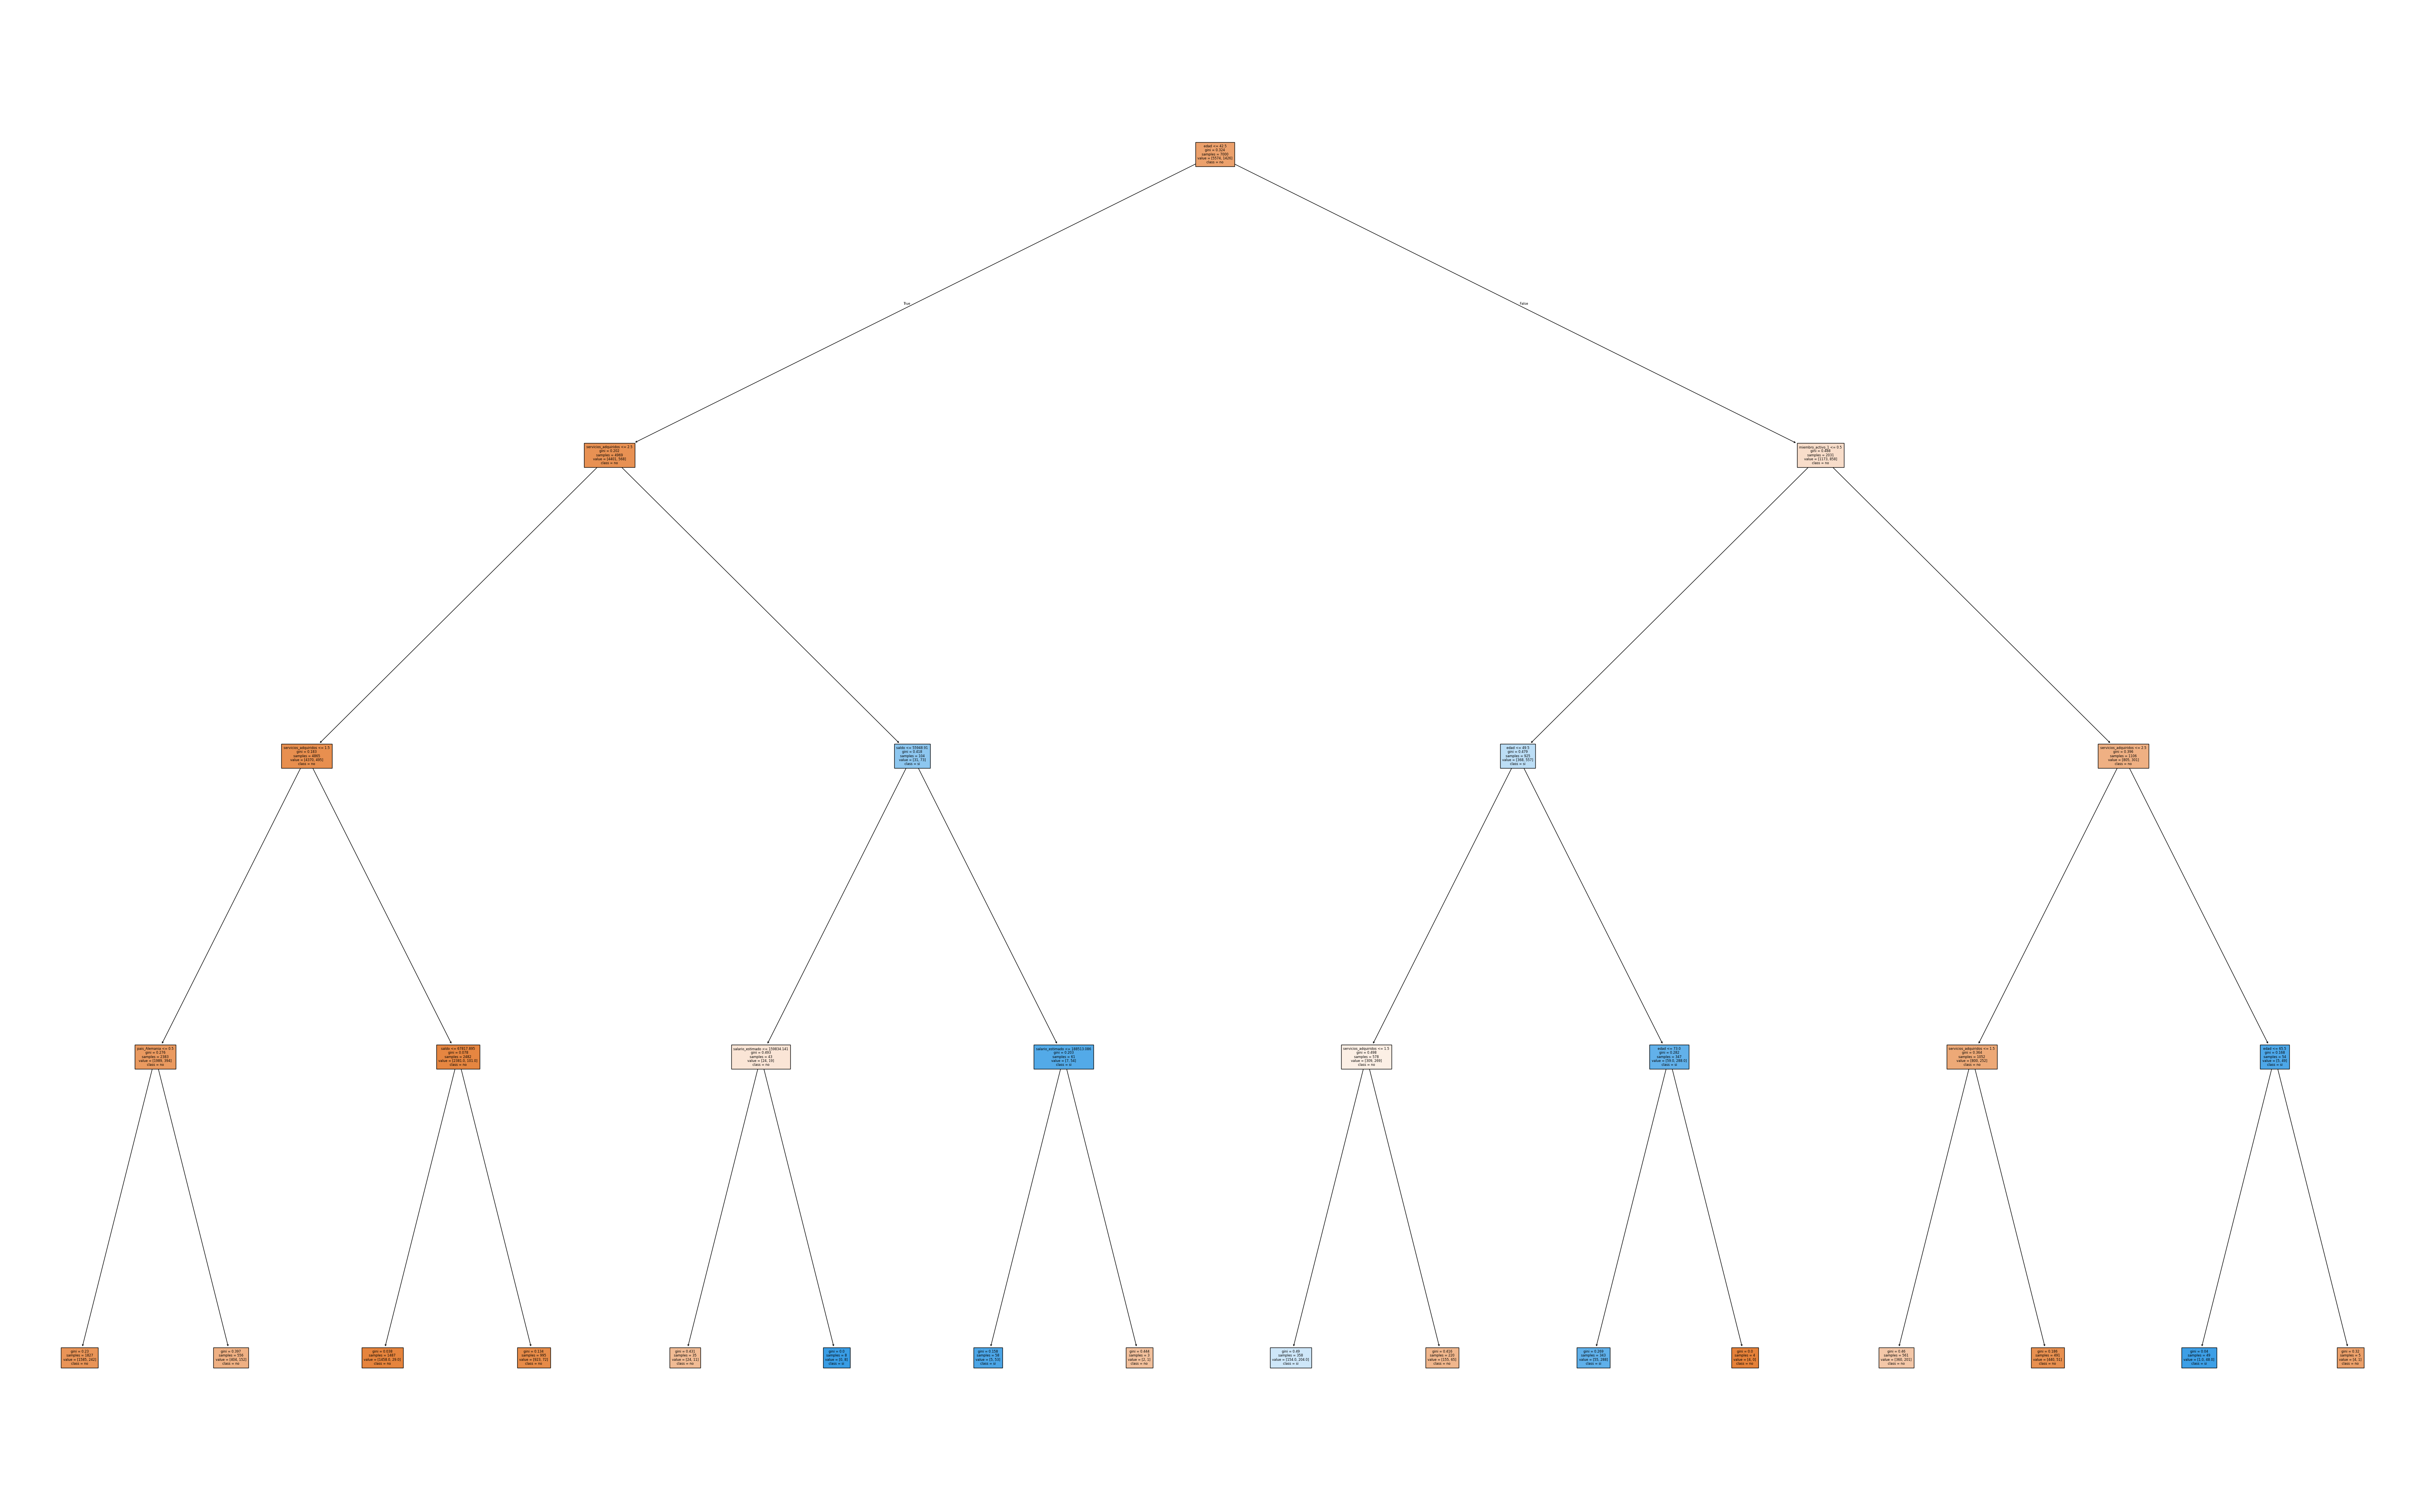

In [152]:
plt.figure(figsize=(80,50))
plot_tree(model_tree_1, filled=True, fontsize=6 , class_names=["no", "si"], feature_names=valores_columnas_1);